# EJERCICIO REGRESIÓN LINEAL MULTIPLE HOUSING PRICE
https://www.kaggle.com/code/tarunsharma404/housing-dataset/input

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/Housing.csv').dropna()
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [4]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


## CORRELACIÓN DE VARIABLES

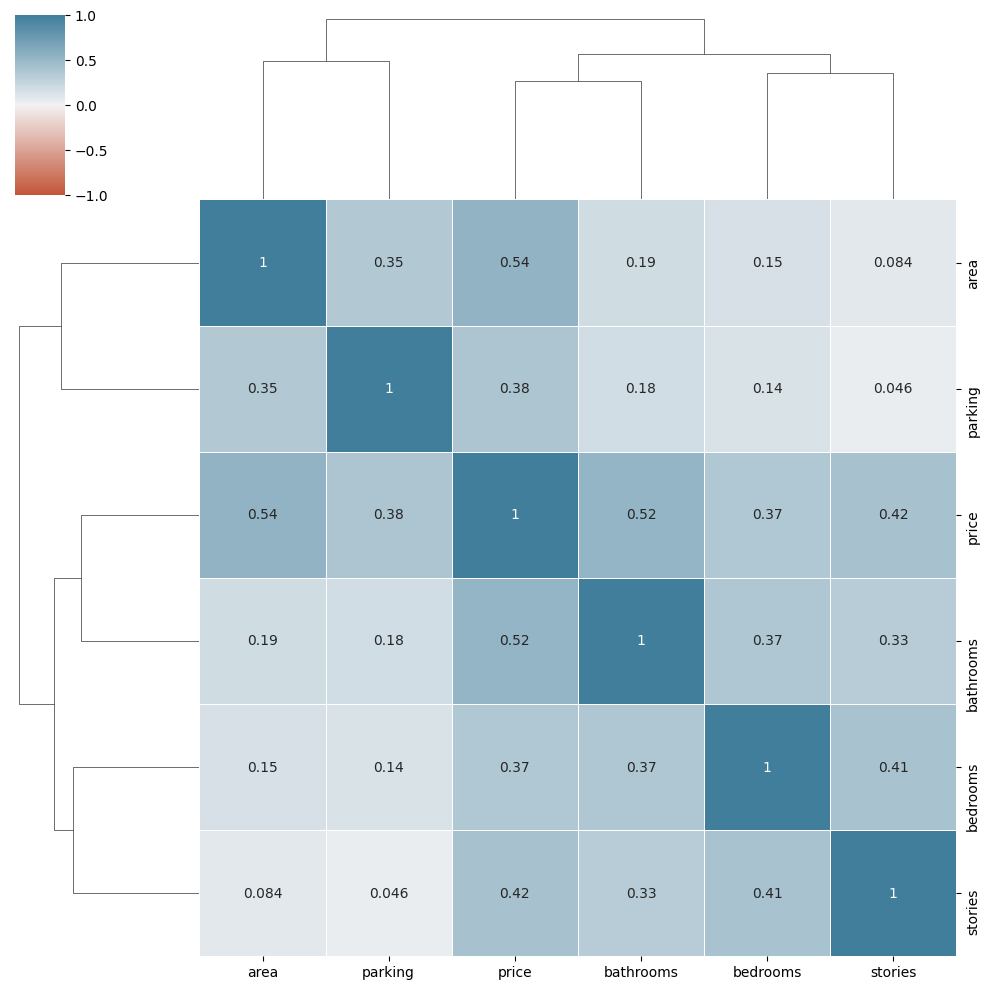

In [6]:
sns.clustermap(
    data=df.corr(numeric_only=True),
    cmap=sns.diverging_palette(20,230,as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink':0.5},
    annot=True
)

## REGRESIÓN LINEAL MULTIPLE

In [7]:
import statsmodels.formula.api as smf

In [8]:
model_1 = (
    smf.ols(
        formula="price ~ area",
        data=df
    )
    .fit()
)
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     218.9
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           7.39e-42
Time:                        02:48:07   Log-Likelihood:                -8551.2
No. Observations:                 545   AIC:                         1.711e+04
Df Residuals:                     543   BIC:                         1.712e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2.387e+06   1.74e+05     13.681      0.000    2.04e+06    2.73e+06
area         461.9749     31.226     14.795      0.000     400.637     523.313
==============================================================================
Omnibus:                       92.668   Durbin-Watson:                   0.565
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              183.673
Skew:                           0.954   Prob(JB):                     1.31e-40
Kurtosis:                       5.108   Cond. No.                     1.44e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.44e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [9]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [10]:
model_2 = (
    smf.ols(
        formula="price ~ area + bathrooms + bedrooms + stories + parking",
        data=df
    )
    .fit()
)
model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.562
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     138.1
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           4.37e-94
Time:                        02:49:37   Log-Likelihood:                -8418.8
No. Observations:                 545   AIC:                         1.685e+04
Df Residuals:                     539   BIC:                         1.688e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.457e+05   2.47e+05     -0.591      0.555    -6.3e+05    3.39e+05
area         331.1155     26.600     12.448      0.000     278.864     383.367
bathrooms   1.134e+06   1.19e+05      9.541      0.000       9e+05    1.37e+06
bedrooms    1.678e+05   8.29e+04      2.023      0.044    4898.893    3.31e+05
stories     5.479e+05   6.89e+04      7.953      0.000    4.13e+05    6.83e+05
parking     3.776e+05   6.68e+04      5.652      0.000    2.46e+05    5.09e+05
==============================================================================
Omnibus:                       69.095   Durbin-Watson:                   1.089
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              149.339
Skew:                           0.704   Prob(JB):                     3.73e-33
Kurtosis:                       5.143   Cond. No.                     2.66e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.66e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [15]:
model_3 = (
    smf.ols(
        formula="price ~ area + bathrooms + bedrooms + stories + parking + + C(mainroad) + C(guestroom)",
        data=df
    )
    .fit()
)
model_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.593
Model:                            OLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                     111.8
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          1.49e-100
Time:                        02:53:39   Log-Likelihood:                -8398.6
No. Observations:                 545   AIC:                         1.681e+04
Df Residuals:                     537   BIC:                         1.685e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -5.217e+05   2.63e+05     -1.986      0.047   -1.04e+06   -5773.853
C(mainroad)[T.yes]   6.039e+05   1.58e+05      3.830      0.000    2.94e+05    9.14e+05
C(guestroom)[T.yes]  6.735e+05   1.37e+05      4.918      0.000    4.05e+05    9.43e+05
area                  291.2432     26.607     10.946      0.000     238.977     343.510
bathrooms            1.099e+06   1.15e+05      9.531      0.000    8.72e+05    1.32e+06
bedrooms               1.9e+05   8.06e+04      2.358      0.019    3.17e+04    3.48e+05
stories              5.138e+05   6.72e+04      7.642      0.000    3.82e+05    6.46e+05
parking              3.544e+05   6.51e+04      5.448      0.000    2.27e+05    4.82e+05
==============================================================================
Omnibus:                       78.534   Durbin-Watson:                   1.097
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              206.856
Skew:                           0.724   Prob(JB):                     1.21e-45
Kurtosis:                       5.648   Cond. No.                     3.03e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.03e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [16]:
model_4 = (
    smf.ols(
        formula="price ~ area + bathrooms + bedrooms + stories + parking + + C(mainroad) + C(guestroom) + C(basement)",
        data=df
    )
    .fit()
)
model_4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     104.0
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          6.06e-104
Time:                        02:53:47   Log-Likelihood:                -8388.1
No. Observations:                 545   AIC:                         1.679e+04
Df Residuals:                     536   BIC:                         1.683e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -5.885e+05   2.58e+05     -2.278      0.023    -1.1e+06    -8.1e+04
C(mainroad)[T.yes]   5.651e+05   1.55e+05      3.644      0.000    2.61e+05     8.7e+05
C(guestroom)[T.yes]  4.284e+05   1.45e+05      2.960      0.003    1.44e+05    7.13e+05
C(basement)[T.yes]    5.45e+05   1.19e+05      4.577      0.000    3.11e+05    7.79e+05
area                  296.2740     26.149     11.330      0.000     244.907     347.641
bathrooms            1.049e+06   1.14e+05      9.230      0.000    8.26e+05    1.27e+06
bedrooms             1.357e+05      8e+04      1.696      0.091   -2.15e+04    2.93e+05
stories              5.995e+05   6.86e+04      8.737      0.000    4.65e+05    7.34e+05
parking              3.493e+05   6.39e+04      5.468      0.000    2.24e+05    4.75e+05
==============================================================================
Omnibus:                       76.518   Durbin-Watson:                   1.118
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              209.585
Skew:                           0.693   Prob(JB):                     3.08e-46
Kurtosis:                       5.703   Cond. No.                     3.04e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.04e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [17]:
model_4 = (
    smf.ols(
        formula="price ~ area + bathrooms + bedrooms + stories + parking + + C(mainroad) + C(guestroom) + C(basement) + C(hotwaterheating)",
        data=df
    )
    .fit()
)
model_4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     93.75
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          5.28e-104
Time:                        02:53:55   Log-Likelihood:                -8385.6
No. Observations:                 545   AIC:                         1.679e+04
Df Residuals:                     535   BIC:                         1.683e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                 -5.967e+05   2.57e+05     -2.318      0.021    -1.1e+06   -9.11e+04
C(mainroad)[T.yes]         5.697e+05   1.54e+05      3.688      0.000    2.66e+05    8.73e+05
C(guestroom)[T.yes]        4.327e+05   1.44e+05      3.000      0.003    1.49e+05    7.16e+05
C(basement)[T.yes]         5.453e+05   1.19e+05      4.597      0.000    3.12e+05    7.78e+05
C(hotwaterheating)[T.yes]  5.437e+05   2.42e+05      2.248      0.025    6.86e+04    1.02e+06
area                        298.5495     26.071     11.452      0.000     247.336     349.763
bathrooms                  1.036e+06   1.13e+05      9.136      0.000    8.13e+05    1.26e+06
bedrooms                   1.318e+05   7.97e+04      1.653      0.099   -2.48e+04    2.88e+05
stories                    6.005e+05   6.84e+04      8.785      0.000    4.66e+05    7.35e+05
parking                    3.397e+05   6.38e+04      5.324      0.000    2.14e+05    4.65e+05
==============================================================================
Omnibus:                       76.555   Durbin-Watson:                   1.127
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              212.152
Skew:                           0.690   Prob(JB):                     8.55e-47
Kurtosis:                       5.727   Cond. No.                     3.04e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.04e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [18]:
model_5 = (
    smf.ols(
        formula="price ~ area + bathrooms + bedrooms + stories + parking + + C(mainroad) + C(guestroom) + C(basement) + C(hotwaterheating) + C(airconditioning)",
        data=df
    )
    .fit()
)
model_5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     100.8
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          4.05e-116
Time:                        02:54:01   Log-Likelihood:                -8354.5
No. Observations:                 545   AIC:                         1.673e+04
Df Residuals:                     534   BIC:                         1.678e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                 -4.132e+05   2.44e+05     -1.691      0.091   -8.93e+05    6.69e+04
C(mainroad)[T.yes]         5.716e+05   1.46e+05      3.914      0.000    2.85e+05    8.59e+05
C(guestroom)[T.yes]        3.487e+05   1.37e+05      2.550      0.011    8.01e+04    6.17e+05
C(basement)[T.yes]          5.01e+05   1.12e+05      4.462      0.000     2.8e+05    7.22e+05
C(hotwaterheating)[T.yes]  8.291e+05   2.31e+05      3.583      0.000    3.74e+05    1.28e+06
C(airconditioning)[T.yes]  9.007e+05   1.12e+05      8.033      0.000     6.8e+05    1.12e+06
area                        270.7051     24.891     10.876      0.000     221.809     319.601
bathrooms                  9.927e+05   1.07e+05      9.247      0.000    7.82e+05     1.2e+06
bedrooms                   1.372e+05   7.54e+04      1.820      0.069   -1.09e+04    2.85e+05
stories                     4.69e+05   6.67e+04      7.033      0.000    3.38e+05       6e+05
parking                    2.947e+05   6.06e+04      4.865      0.000    1.76e+05    4.14e+05
==============================================================================
Omnibus:                       87.777   Durbin-Watson:                   1.182
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              242.288
Skew:                           0.791   Prob(JB):                     2.44e-53
Kurtosis:                       5.858   Cond. No.                     3.05e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.05e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [19]:
model_6 = (
    smf.ols(
        formula="price ~ area + bathrooms + bedrooms + stories + parking + C(mainroad) + C(guestroom) + C(basement) + C(hotwaterheating) + C(airconditioning) + C(prefarea)",
        data=df
    )
    .fit()
)
model_6.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.673
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     99.81
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          1.01e-121
Time:                        02:54:30   Log-Likelihood:                -8338.8
No. Observations:                 545   AIC:                         1.670e+04
Df Residuals:                     533   BIC:                         1.675e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                 -2.831e+05   2.39e+05     -1.185      0.236   -7.52e+05    1.86e+05
C(mainroad)[T.yes]         4.665e+05   1.43e+05      3.256      0.001    1.85e+05    7.48e+05
C(guestroom)[T.yes]        3.173e+05   1.33e+05      2.384      0.017    5.58e+04    5.79e+05
C(basement)[T.yes]          3.82e+05   1.11e+05      3.434      0.001    1.63e+05       6e+05
C(hotwaterheating)[T.yes]  8.979e+05   2.25e+05      3.984      0.000    4.55e+05    1.34e+06
C(airconditioning)[T.yes]  8.803e+05   1.09e+05      8.068      0.000    6.66e+05    1.09e+06
C(prefarea)[T.yes]         6.577e+05   1.17e+05      5.624      0.000    4.28e+05    8.87e+05
area                        248.1692     24.535     10.115      0.000     199.971     296.367
bathrooms                  1.006e+06   1.04e+05      9.633      0.000    8.01e+05    1.21e+06
bedrooms                   1.285e+05   7.33e+04      1.752      0.080   -1.56e+04    2.73e+05
stories                    4.571e+05   6.49e+04      7.046      0.000     3.3e+05    5.85e+05
parking                    2.985e+05   5.89e+04      5.067      0.000    1.83e+05    4.14e+05
==============================================================================
Omnibus:                       93.420   Durbin-Watson:                   1.189
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              247.123
Skew:                           0.854   Prob(JB):                     2.18e-54
Kurtosis:                       5.822   Cond. No.                     3.07e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.07e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [20]:
model_7 = (
    smf.ols(
        formula="price ~ area + bathrooms + bedrooms + stories + parking + C(mainroad) + C(guestroom) + C(basement) + C(hotwaterheating) + C(airconditioning) + C(prefarea) + C(furnishingstatus)",
        data=df
    )
    .fit()
)
model_7.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     87.52
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          9.07e-123
Time:                        02:55:12   Log-Likelihood:                -8331.5
No. Observations:                 545   AIC:                         1.669e+04
Df Residuals:                     531   BIC:                         1.675e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                              4.277e+04   2.64e+05      0.162      0.872   -4.76e+05    5.62e+05
C(mainroad)[T.yes]                     4.213e+05   1.42e+05      2.962      0.003    1.42e+05    7.01e+05
C(guestroom)[T.yes]                    3.005e+05   1.32e+05      2.282      0.023    4.18e+04    5.59e+05
C(basement)[T.yes]                     3.501e+05    1.1e+05      3.175      0.002    1.33e+05    5.67e+05
C(hotwaterheating)[T.yes]              8.554e+05   2.23e+05      3.833      0.000    4.17e+05    1.29e+06
C(airconditioning)[T.yes]               8.65e+05   1.08e+05      7.983      0.000    6.52e+05    1.08e+06
C(prefarea)[T.yes]                     6.515e+05   1.16e+05      5.632      0.000    4.24e+05    8.79e+05
C(furnishingstatus)[T.semi-furnished] -4.634e+04   1.17e+05     -0.398      0.691   -2.75e+05    1.83e+05
C(furnishingstatus)[T.unfurnished]    -4.112e+05   1.26e+05     -3.258      0.001   -6.59e+05   -1.63e+05
area                                    244.1394     24.289     10.052      0.000     196.425     291.853
bathrooms                              9.877e+05   1.03e+05      9.555      0.000    7.85e+05    1.19e+06
bedrooms                               1.148e+05   7.26e+04      1.581      0.114   -2.78e+04    2.57e+05
stories                                4.508e+05   6.42e+04      7.026      0.000    3.25e+05    5.77e+05
parking                                2.771e+05   5.85e+04      4.735      0.000    1.62e+05    3.92e+05
==============================================================================
Omnibus:                       97.909   Durbin-Watson:                   1.209
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              258.281
Skew:                           0.895   Prob(JB):                     8.22e-57
Kurtosis:                       5.859   Cond. No.                     3.49e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.49e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## COMPARAMOS LOS MODELOS

In [26]:
model_1_predict = model_1.predict(df)
model_2_predict = model_2.predict(df)
model_3_predict = model_3.predict(df)
model_4_predict = model_4.predict(df)
model_5_predict = model_5.predict(df)
model_6_predict = model_6.predict(df)
model_7_predict = model_7.predict(df)

In [ ]:
dic_predict = {
    'actual_value':df.price,
    'model_1_predict':model_1_predict,
    'model_2_predict':model_2_predict,
    'model_3_predict':model_3_predict,
    'model_4_predict':model_4_predict,
    'model_5_predict':model_5_predict,
    'model_6_predict':model_6_predict,
    'model_7_predict':model_7_predict
}

models_result = pd.DataFrame(dic_predict)
models_result.style.format("{:,.2f}")

In [30]:
%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_context(context='notebook')
plt.rcParams['figure.figsize'] = (11, 9.4)

<Axes: ylabel='Proportion'>

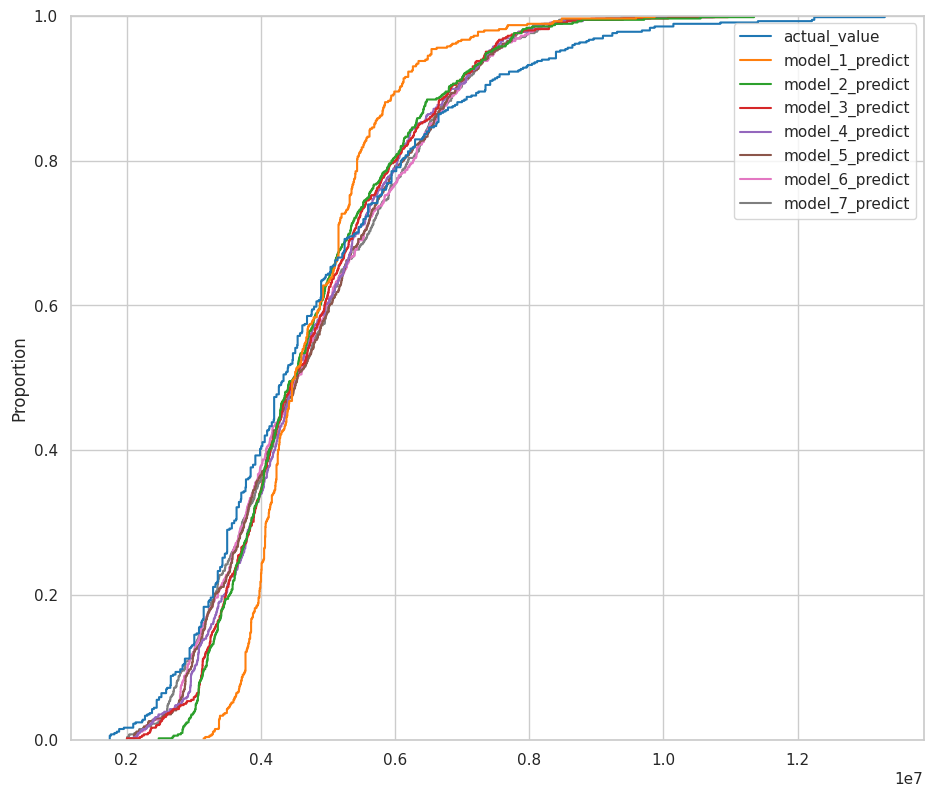

In [31]:
sns.ecdfplot(
    data=models_result
)

<Axes: ylabel='Proportion'>

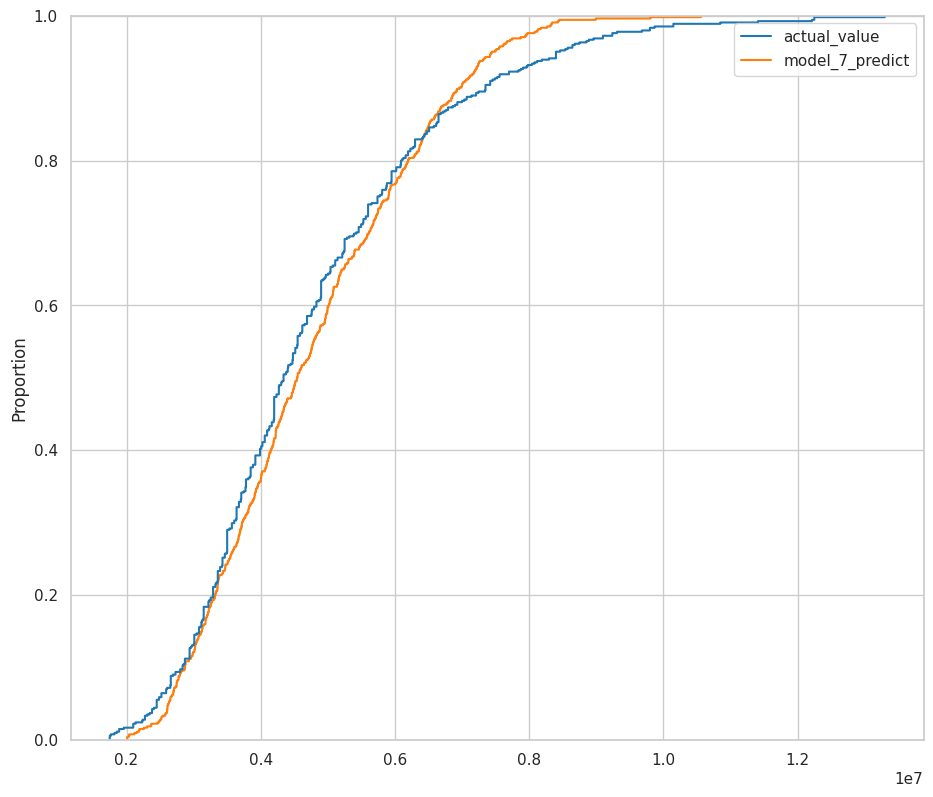

In [32]:
sns.ecdfplot(data=models_result[['actual_value','model_7_predict']])